# Retail Analytics — Trial vs Control Store Analysis
## Project: Quantium Virtual Experience (Forage)
### Notebook: 02 — Trial vs Control Assessment
### Tools: pandas, matplotlib
### Goal: Identify control stores for trial stores 77, 86, and 88, assess whether the trial drove uplift in sales and customers, and provide a recommendation for Julia based on the evidence.

# 1. Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '../data/'

df = pd.read_csv(DATA_PATH + 'QVI_data_clean.csv', parse_dates=['DATE'])

print(f'Shape: {df.shape}')
print(f'Date range: {df["DATE"].min()} to {df["DATE"].max()}')
print(df.head())

Shape: (245302, 12)
Date range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00
        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2018-08-17          2            2373     974        69   
4 2018-08-18          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES PACK_SIZE  \
0           Natural Chip Compny SeaSalt175g         2        6.0      175G   
1                     CCs Nacho Cheese 175g         3        6.3      175G   
2     Smiths Crinkle Cut Chips Chicken 170g         2        2.9      170G   
3     Smiths Chip Thinly S/Cream&Onion 175g         5       15.0      175G   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8      150G   

     BRAND               LIFESTAGE PREMIUM_CUSTOMER  
0  Natural   YOUNG SINGLES/COUPLES 

# 2. Aggregate to store-month level

In [2]:
df['YEARMONTH'] = df['DATE'].dt.to_period('M')

store_monthly = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    total_sales    = ('TOT_SALES', 'sum'),
    num_customers  = ('LYLTY_CARD_NBR', 'nunique'),
    num_txns       = ('TXN_ID', 'nunique'),
    avg_txns_per_customer = ('TXN_ID', 'nunique')
).reset_index()

# Fix avg transactions per customer
store_monthly['avg_txns_per_customer'] = store_monthly['num_txns'] / store_monthly['num_customers']

print(f'Store-month records: {len(store_monthly)}')
print(store_monthly.head(12))

Store-month records: 3165
    STORE_NBR YEARMONTH  total_sales  num_customers  num_txns  \
0           1   2018-07        188.9             47        49   
1           1   2018-08        168.4             41        41   
2           1   2018-09        268.1             57        59   
3           1   2018-10        175.4             39        40   
4           1   2018-11        184.8             44        45   
5           1   2018-12        160.6             37        40   
6           1   2019-01        144.5             33        33   
7           1   2019-02        192.1             48        50   
8           1   2019-03        185.2             43        47   
9           1   2019-04        177.4             39        40   
10          1   2019-05        201.9             41        46   
11          1   2019-06        161.0             38        38   

    avg_txns_per_customer  
0                1.042553  
1                1.000000  
2                1.035088  
3               

# 3. Define trial and pre-trial periods

In [3]:
# Trial ran from February 2019 to April 2019
# Pre-trial is July 2018 to January 2019

trial_stores = [77, 86, 88]

pre_trial = store_monthly[store_monthly['YEARMONTH'] < '2019-02']
trial     = store_monthly[store_monthly['YEARMONTH'].isin(
                pd.period_range('2019-02', '2019-04', freq='M'))]

print(f'Pre-trial months: {pre_trial["YEARMONTH"].unique()}')
print(f'Trial months:     {trial["YEARMONTH"].unique()}')
print(f'\nPre-trial records: {len(pre_trial)}')
print(f'Trial records:     {len(trial)}')

# Confirm trial stores exist in data
print(f'\nTrial stores in data: {store_monthly[store_monthly["STORE_NBR"].isin(trial_stores)]["STORE_NBR"].unique()}')

Pre-trial months: <PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]
Trial months:     <PeriodArray>
['2019-02', '2019-03', '2019-04']
Length: 3, dtype: period[M]

Pre-trial records: 1846
Trial records:     792

Trial stores in data: [77 86 88]


# 4. Control store selection

In [4]:
# Score each store by similarity to trial stores across pre-trial period
# Metrics: total_sales, num_customers — normalised to make them comparable

from scipy.stats import pearsonr
import numpy as np

def get_similarity(trial_store, candidate_store, metrics=['total_sales', 'num_customers']):
    scores = []
    for metric in metrics:
        trial_data     = pre_trial[pre_trial['STORE_NBR'] == trial_store][metric].values
        candidate_data = pre_trial[pre_trial['STORE_NBR'] == candidate_store][metric].values

        if len(trial_data) != len(candidate_data):
            return None

        # Pearson correlation — measures similarity of trend
        corr, _ = pearsonr(trial_data, candidate_data)

        # Magnitude difference — bounded between 0 and 1
        mag_diff = 1 - abs(trial_data.mean() - candidate_data.mean()) / (trial_data.mean() + candidate_data.mean())

        # Combined score per metric
        scores.append((corr + mag_diff) / 2)

    # Average score across all metrics
    return np.mean(scores)

all_stores = store_monthly['STORE_NBR'].unique()

for trial_store in trial_stores:
    scores = {}
    for store in all_stores:
        if store == trial_store:
            continue
        score = get_similarity(trial_store, store)
        if score is not None:
            scores[store] = score

    top5 = sorted(scores, key=scores.get, reverse=True)[:5]
    print(f'\nTrial store {trial_store} — Top 5 control candidates:')
    for s in top5:
        print(f'  Store {s}: score {scores[s]:.4f}')


Trial store 77 — Top 5 control candidates:
  Store 233: score 0.9657
  Store 50: score 0.8567
  Store 53: score 0.7999
  Store 167: score 0.7897
  Store 35: score 0.7800

Trial store 86 — Top 5 control candidates:
  Store 155: score 0.9116
  Store 114: score 0.8809
  Store 138: score 0.8308
  Store 56: score 0.7955
  Store 78: score 0.7775

Trial store 88 — Top 5 control candidates:
  Store 237: score 0.7654
  Store 123: score 0.7323
  Store 7: score 0.7088
  Store 178: score 0.7046
  Store 91: score 0.6926


# 5. Visualise control store matches — pre-trial sales trends

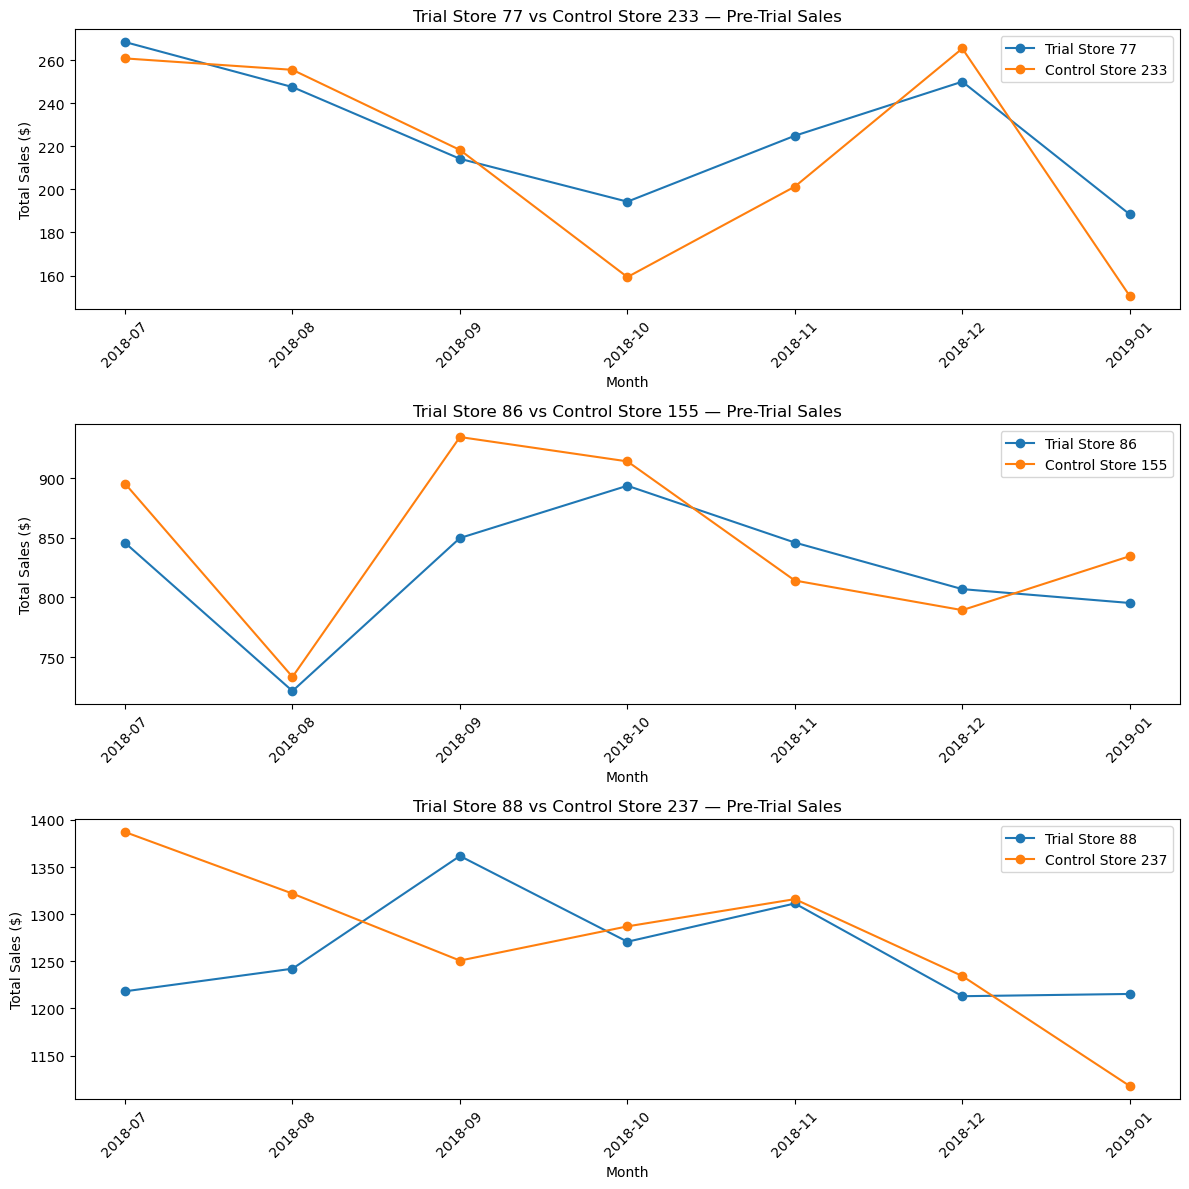

Chart saved to outputs/


In [5]:
control_stores = {77: 233, 86: 155, 88: 237}

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, (trial_store, control_store) in enumerate(control_stores.items()):
    trial_data   = pre_trial[pre_trial['STORE_NBR'] == trial_store]
    control_data = pre_trial[pre_trial['STORE_NBR'] == control_store]

    axes[i].plot(trial_data['YEARMONTH'].astype(str),   trial_data['total_sales'],   marker='o', label=f'Trial Store {trial_store}')
    axes[i].plot(control_data['YEARMONTH'].astype(str), control_data['total_sales'], marker='o', label=f'Control Store {control_store}')
    axes[i].set_title(f'Trial Store {trial_store} vs Control Store {control_store} — Pre-Trial Sales')
    axes[i].set_ylabel('Total Sales ($)')
    axes[i].set_xlabel('Month')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/control_store_match_sales.png', dpi=150)
plt.show()
print('Chart saved to outputs/')

# 6. Visualise control store matches — pre-trial customer counts

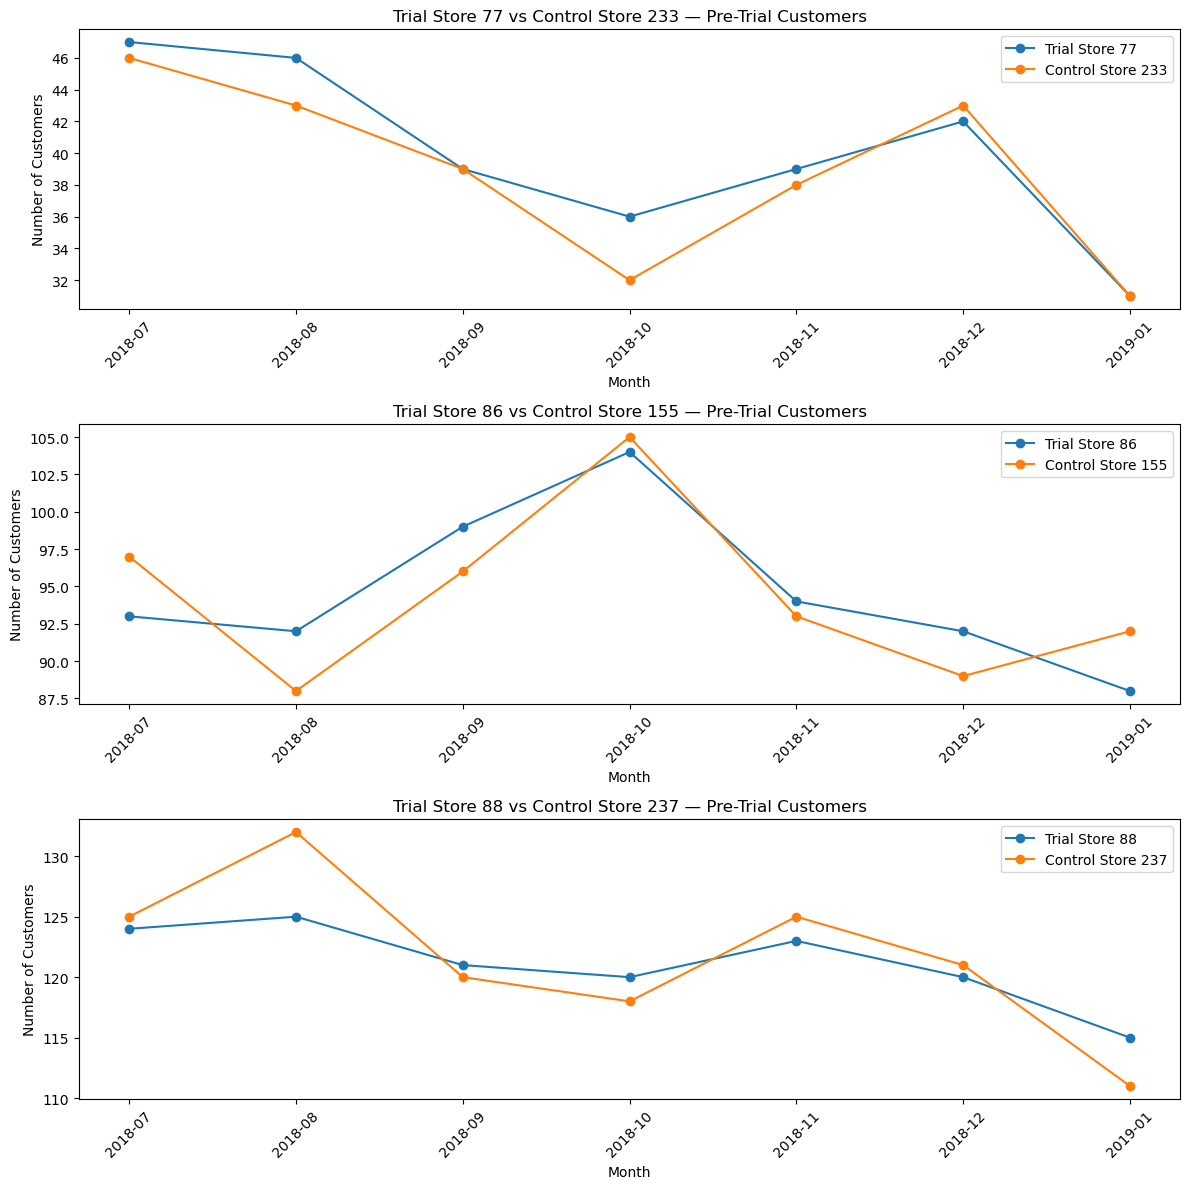

Chart saved to outputs/


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, (trial_store, control_store) in enumerate(control_stores.items()):
    trial_data   = pre_trial[pre_trial['STORE_NBR'] == trial_store]
    control_data = pre_trial[pre_trial['STORE_NBR'] == control_store]

    axes[i].plot(trial_data['YEARMONTH'].astype(str),   trial_data['num_customers'],   marker='o', label=f'Trial Store {trial_store}')
    axes[i].plot(control_data['YEARMONTH'].astype(str), control_data['num_customers'], marker='o', label=f'Control Store {control_store}')
    axes[i].set_title(f'Trial Store {trial_store} vs Control Store {control_store} — Pre-Trial Customers')
    axes[i].set_ylabel('Number of Customers')
    axes[i].set_xlabel('Month')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/control_store_match_customers.png', dpi=150)
plt.show()
print('Chart saved to outputs/')

# 7a. Trial period assessment — sales comparison

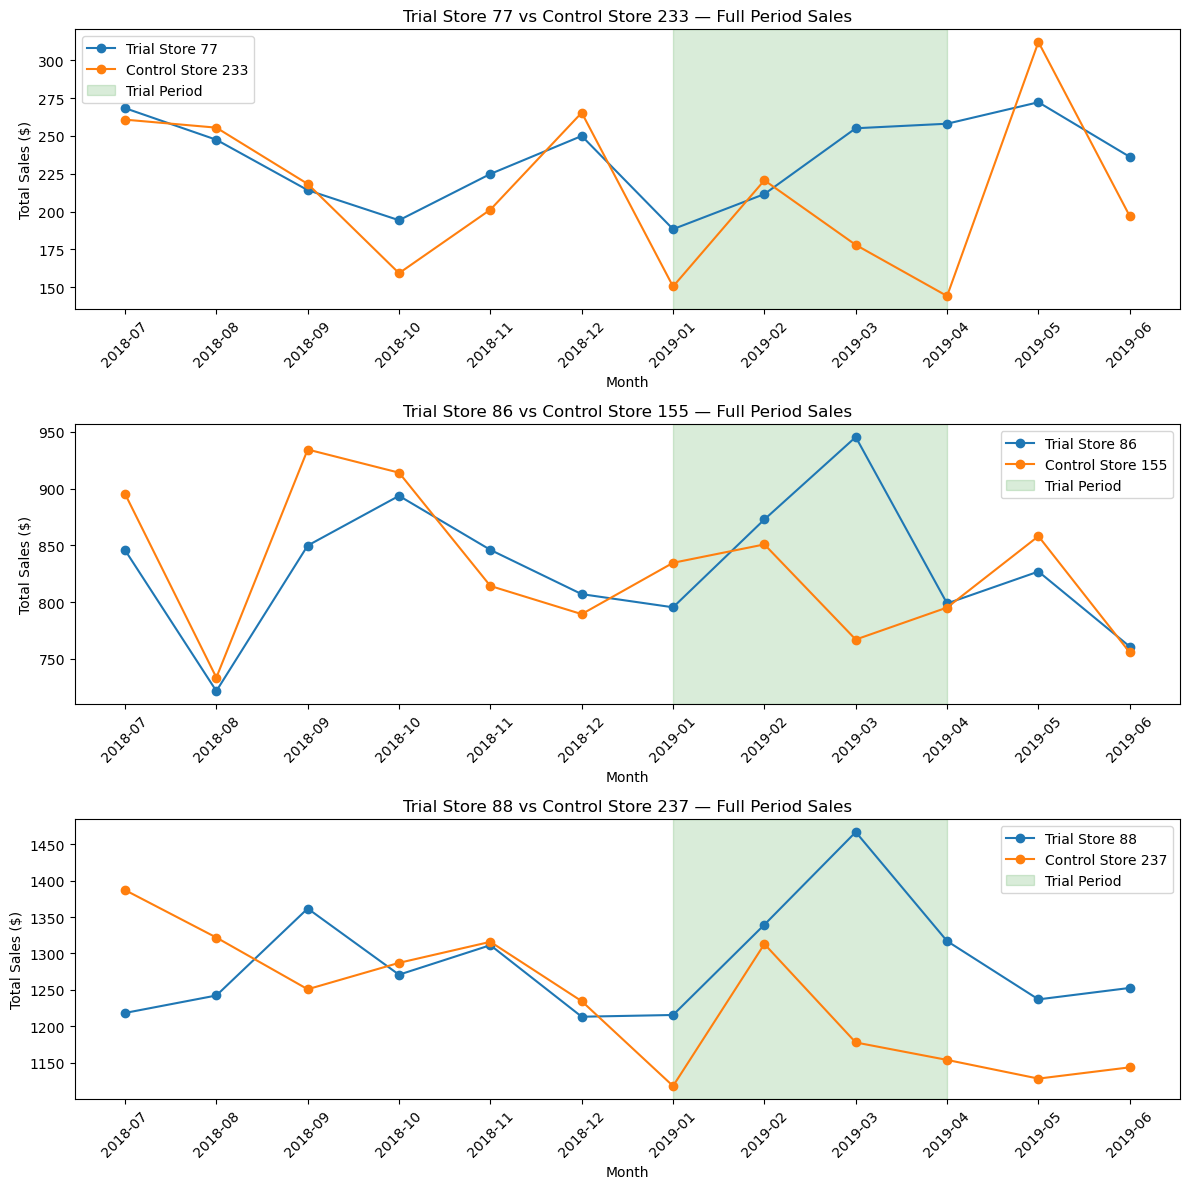

In [7]:
all_data = store_monthly.copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, (trial_store, control_store) in enumerate(control_stores.items()):
    trial_data   = all_data[all_data['STORE_NBR'] == trial_store]
    control_data = all_data[all_data['STORE_NBR'] == control_store]

    axes[i].plot(trial_data['YEARMONTH'].astype(str),   trial_data['total_sales'],   marker='o', label=f'Trial Store {trial_store}')
    axes[i].plot(control_data['YEARMONTH'].astype(str), control_data['total_sales'], marker='o', label=f'Control Store {control_store}')
    axes[i].axvspan(6, 9, alpha=0.15, color='green', label='Trial Period')
    axes[i].set_title(f'Trial Store {trial_store} vs Control Store {control_store} — Full Period Sales')
    axes[i].set_ylabel('Total Sales (\$)')
    axes[i].set_xlabel('Month')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/trial_assessment_sales.png', dpi=150)
plt.show()

# 7b. Fix trial period shading — Full Period Sales

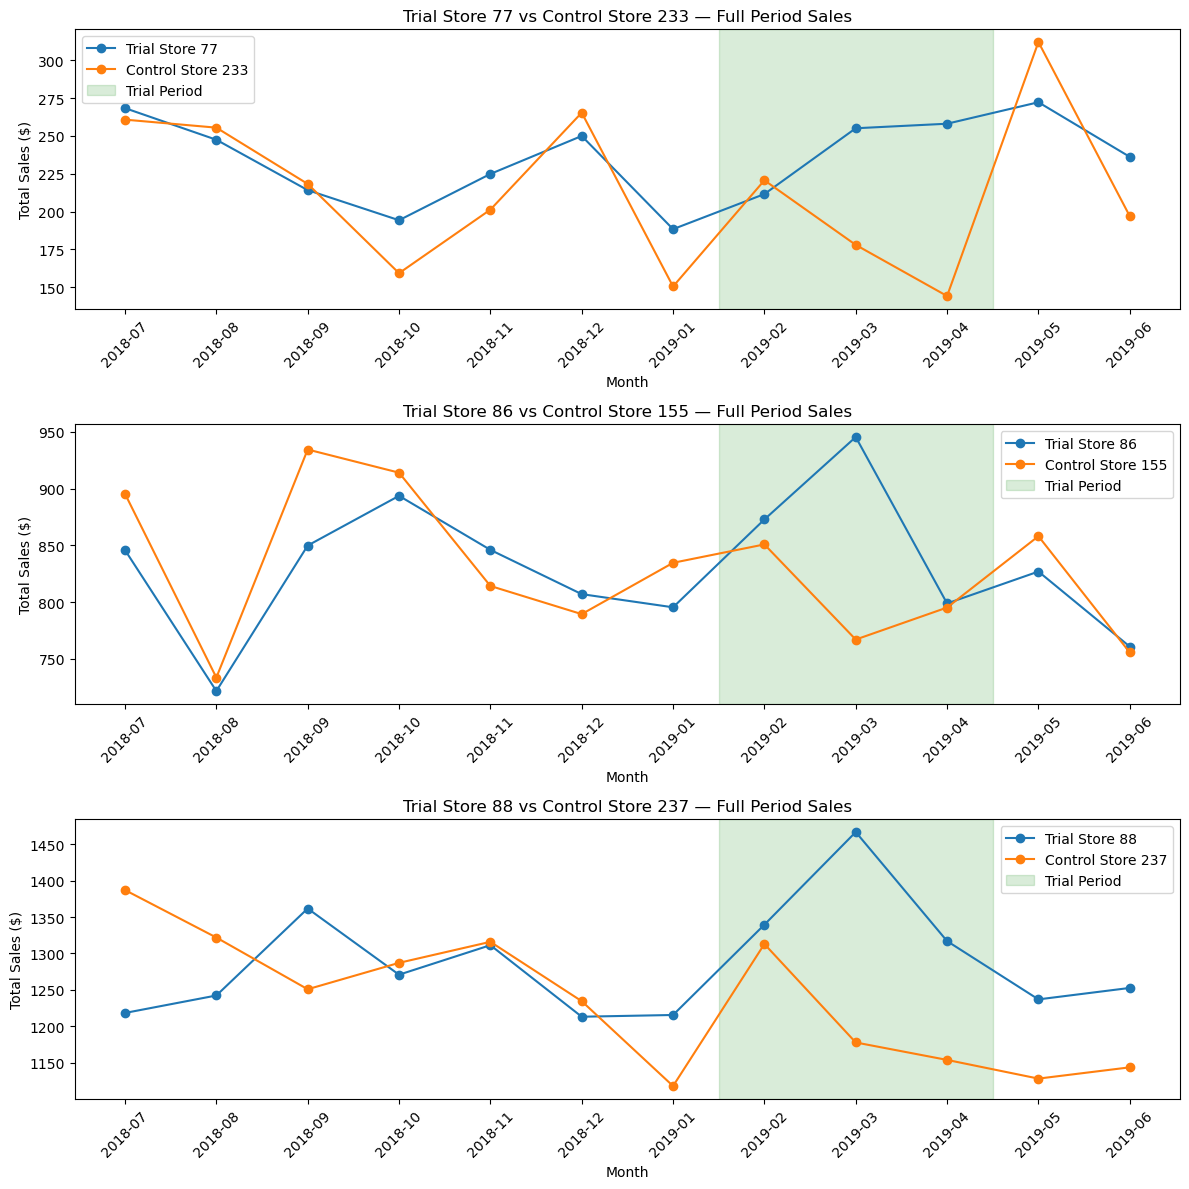

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

trial_start = '2019-02'
trial_end   = '2019-04'

for i, (trial_store, control_store) in enumerate(control_stores.items()):
    trial_data   = all_data[all_data['STORE_NBR'] == trial_store].sort_values('YEARMONTH')
    control_data = all_data[all_data['STORE_NBR'] == control_store].sort_values('YEARMONTH')

    months = trial_data['YEARMONTH'].astype(str).tolist()
    start_idx = months.index(trial_start)
    end_idx   = months.index(trial_end)

    axes[i].plot(months, trial_data['total_sales'].values,   marker='o', label=f'Trial Store {trial_store}')
    axes[i].plot(months, control_data['total_sales'].values, marker='o', label=f'Control Store {control_store}')
    axes[i].axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.15, color='green', label='Trial Period')
    axes[i].set_title(f'Trial Store {trial_store} vs Control Store {control_store} — Full Period Sales')
    axes[i].set_ylabel('Total Sales (\$)')
    axes[i].set_xlabel('Month')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/trial_assessment_sales.png', dpi=150)
plt.show()

# 8. Calculate sales uplift during trial period

In [9]:
trial_period_months = ['2019-02', '2019-03', '2019-04']

print('=== SALES UPLIFT DURING TRIAL PERIOD ===\n')
for trial_store, control_store in control_stores.items():
    t = store_monthly[
        (store_monthly['STORE_NBR'] == trial_store) & 
        (store_monthly['YEARMONTH'].astype(str).isin(trial_period_months))
    ]['total_sales'].sum()
    
    c = store_monthly[
        (store_monthly['STORE_NBR'] == control_store) & 
        (store_monthly['YEARMONTH'].astype(str).isin(trial_period_months))
    ]['total_sales'].sum()
    
    uplift     = t - c
    uplift_pct = (uplift / c) * 100
    
    print(f'Trial Store {trial_store} vs Control Store {control_store}:')
    print(f'  Trial sales:   ${t:,.2f}')
    print(f'  Control sales: ${c:,.2f}')
    print(f'  Uplift:        ${uplift:,.2f} ({uplift_pct:.1f}%)')
    print()

=== SALES UPLIFT DURING TRIAL PERIOD ===

Trial Store 77 vs Control Store 233:
  Trial sales:   $724.80
  Control sales: $542.90
  Uplift:        $181.90 (33.5%)

Trial Store 86 vs Control Store 155:
  Trial sales:   $2,617.00
  Control sales: $2,413.00
  Uplift:        $204.00 (8.5%)

Trial Store 88 vs Control Store 237:
  Trial sales:   $4,123.60
  Control sales: $3,644.20
  Uplift:        $479.40 (13.2%)



# 9. Calculate customer uplift during trial period

In [10]:
print('=== CUSTOMER UPLIFT DURING TRIAL PERIOD ===\n')
for trial_store, control_store in control_stores.items():
    t = store_monthly[
        (store_monthly['STORE_NBR'] == trial_store) & 
        (store_monthly['YEARMONTH'].astype(str).isin(trial_period_months))
    ]['num_customers'].sum()
    
    c = store_monthly[
        (store_monthly['STORE_NBR'] == control_store) & 
        (store_monthly['YEARMONTH'].astype(str).isin(trial_period_months))
    ]['num_customers'].sum()
    
    uplift     = t - c
    uplift_pct = (uplift / c) * 100
    
    print(f'Trial Store {trial_store} vs Control Store {control_store}:')
    print(f'  Trial customers:   {t}')
    print(f'  Control customers: {c}')
    print(f'  Uplift:            {uplift} ({uplift_pct:.1f}%)')
    print()

=== CUSTOMER UPLIFT DURING TRIAL PERIOD ===

Trial Store 77 vs Control Store 233:
  Trial customers:   133
  Control customers: 103
  Uplift:            30 (29.1%)

Trial Store 86 vs Control Store 155:
  Trial customers:   311
  Control customers: 276
  Uplift:            35 (12.7%)

Trial Store 88 vs Control Store 237:
  Trial customers:   374
  Control customers: 351
  Uplift:            23 (6.6%)



## Task 2 — Trial vs Control Store Findings

### Control Store Selection
- Trial Store 77 → Control Store 233 (similarity score: 0.9657 — strong match)
- Trial Store 86 → Control Store 155 (similarity score: 0.9116 — moderate match)
- Trial Store 88 → Control Store 237 (similarity score: 0.7654 — weakest match)

### Sales Uplift During Trial Period (Feb–Apr 2019)
- Store 77: trial sales of 724.80 vs control 542.90 — uplift of 181.90 (33.5%)  
- Store 86: trial sales of 2,617.00 vs control 2,413.00 — uplift of 204.00 (8.5%)  
- Store 88: trial sales of 4,123.60 vs control 3,644.20 — uplift of 479.40 (13.2%)  

### Customer Uplift During Trial Period (Feb–Apr 2019)
- Store 77: 133 vs 103 customers — uplift of 30 customers (29.1%)
- Store 86: 311 vs 276 customers — uplift of 35 customers (12.7%)
- Store 88: 374 vs 351 customers — uplift of 23 customers (6.6%)

### Recommendations for Julia

1. **Store 77 — Strong positive result**  
   The trial delivered the highest uplift of all three stores: 33.5% in sales
   and 29.1% in customers against a well-matched control store. This result
   is the most reliable of the three. The trial format should be considered
   for rollout to stores with a similar profile to store 77.

2. **Store 86 — Moderate positive result**  
   Sales uplift of 8.5% and customer uplift of 12.7% during the trial period.
   The control match was moderate, so this result should be interpreted with
   some caution. The direction is positive and consistent across both metrics.

3. **Store 88 — Positive result, interpret with caution**  
   Sales uplift of 13.2% and customer uplift of 6.6%. However, the control
   store match was the weakest of the three (score: 0.7654), and the control
   store showed an unusual sales decline entering the trial period. The uplift
   observed may partially reflect the control store underperforming rather than
   the trial store outperforming. Further validation with a better-matched
   control store is recommended before drawing firm conclusions.

### Overall Recommendation
All three trial stores outperformed their selected control stores during the trial period in both sales and customer counts. Store 77 provides the strongest evidence of a positive trial impact due to its high uplift and strong control-store similarity. Store 86 shows a moderate positive result with a reasonably matched control store. Results for Store 88 are positive but should be interpreted with greater caution due to the weakest control-store match of the three.